In [1]:
# Add the parent directory of the current working directory to the Python path at runtime. 
# In order to import modules from the src directory.
import os
import sys 

current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
sys.path.insert(0, parent_dir)

In [2]:
import tomllib

import numpy as np
import matplotlib.pyplot as plt

from src.sim_utils import generate_time_index
from src.anl_utils import order_parameter
from src.stimulus_generator import StimulusGenerator
from src.v1_model import V1Model

In [3]:
def load_configurations():
    """
    Load the model, stimulus, simulation, and experiment parameters.

    Returns
    -------
    model_parameters : dict
        The model parameters.
    stimulus_parameters : dict
        The stimulus parameters.
    simulation_parameters : dict
        The simulation parameters.
    experiment_parameters : dict
        The experiment parameters.
    """
    parameters = {}
    config_files = ['model', 'stimulus', 'simulation']

    for config_file in config_files:
        with open(f'../config/simulation/{config_file}.toml', 'rb') as f:
            parameters[config_file] = tomllib.load(f)

    with open('../config/analysis/experiment_actual.toml', 'rb') as f:
        parameters['experiment'] = tomllib.load(f)

    return parameters['model'], parameters['stimulus'], parameters[
        'simulation'], parameters['experiment']


In [4]:
model_parameters, stimulus_parameters, simulation_parameters, experiment_parameters = load_configurations()
simulation_parameters['num_time_steps'] = int(
        simulation_parameters['simulation_time'] /
        simulation_parameters['time_step'])

In [5]:
stimulus_generator = StimulusGenerator(stimulus_parameters)
scaling_factor = 1.

mean_contrast = experiment_parameters['mean_contrast']

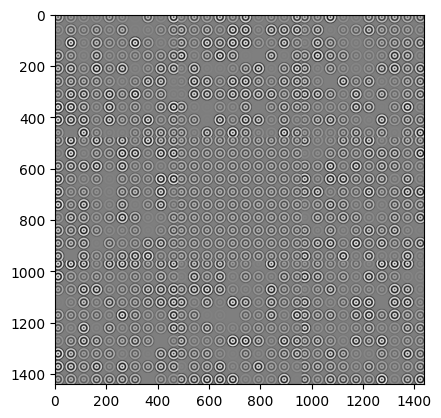

In [6]:
large_stimulus_resolution = int(stimulus_parameters['stimulus_resolution'] * 3)

stimulus = np.zeros((large_stimulus_resolution, large_stimulus_resolution))

for i in range(3):
    for j in range(3):
        if (i==1 and j==1):
            contrast_range = 0.
        else:
            contrast_range = 1

        stimulus[i*stimulus_parameters['stimulus_resolution']:(i+1)*stimulus_parameters['stimulus_resolution'],
                 j*stimulus_parameters['stimulus_resolution']:(j+1)*stimulus_parameters['stimulus_resolution']] = stimulus_generator.generate(scaling_factor, contrast_range, mean_contrast)
                

plt.imshow(stimulus, cmap='gray')

In [7]:
stimulus_parameters['stimulus_resolution'] = large_stimulus_resolution
stimulus_parameters['stimulus_num_pixels'] = large_stimulus_resolution**2
stimulus_parameters['stimulus_side_length'] = stimulus_parameters['stimulus_side_length'] * 3

model_parameters['num_populations'] = 40**2

In [8]:
3*6.7/2

10.05

In [9]:
stimulus_parameters

{'stimulus_resolution': 1440,
 'stimulus_num_pixels': 2073600,
 'stimulus_eccentricity': 7,
 'stimulus_side_length': 20.1,
 'annulus_diameter': 0.7,
 'annulus_frequency': 5.7,
 'annulus_resolution': 50}

In [10]:
model = V1Model(model_parameters, stimulus_parameters)
model.compute_omega(stimulus.flatten())

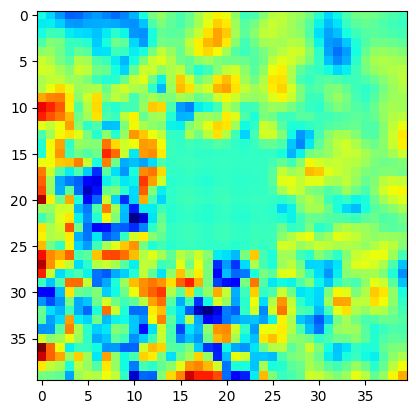

In [12]:
plt.imshow(model.omega.reshape(40,40), cmap='jet')

In [13]:
state, time_vector = model.simulate(simulation_parameters)

In [22]:
sync_index, _ = generate_time_index(simulation_parameters)
figure = state.reshape(-1, 40, 40)[:,15:22,15:22].reshape(-1,49)
background = state.reshape(-1, 40, 40)[:,0:10,0:10].reshape(-1,100)
synchronization = np.abs(order_parameter(figure))
print(f'synchrony within figure = {np.mean(synchronization[sync_index])}')
synchronization = np.abs(order_parameter(background))
print(f'synchrony within background = {np.mean(synchronization[sync_index])}')

synchrony within figure = 0.74043383888167
synchrony within background = 0.06211554205304599


(1000,)
(1000, 1600)
(1600,)


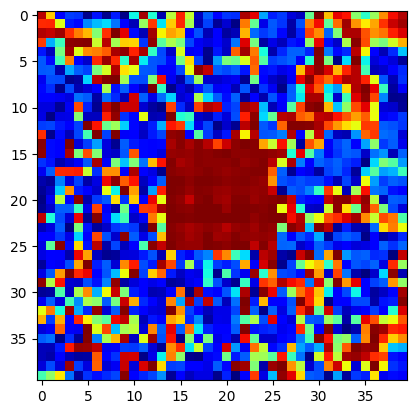

In [48]:
reference = state[:,18*40+18]

print(reference.shape)

phase_differences = state - np.expand_dims(reference, axis=1)

plv = np.abs(np.mean(np.exp(1j*phase_differences[sync_index]), axis=0))
print(phase_differences.shape)
print(plv.shape)

plt.imshow(plv.reshape(40,40), cmap='jet', vmin=0, vmax=1)

In [ ]:
#phase locking value equation: plv = |<e^(i*delta_phi)>| where delta_phi is the phase difference between two signals

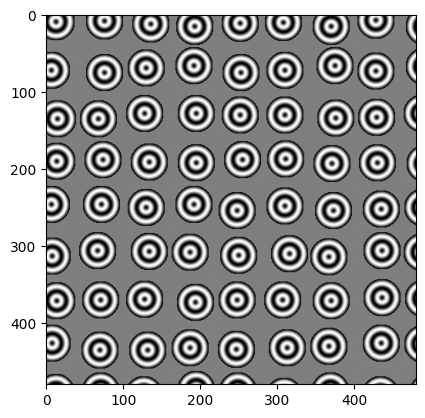

In [ ]:

contrast_range = 0.
# fix the seed for reproducibility
np.random.seed(5)
stimulus_right = stimulus_generator.generate(scaling_factor, contrast_range, mean_contrast)

plt.imshow(stimulus_right, cmap='gray')

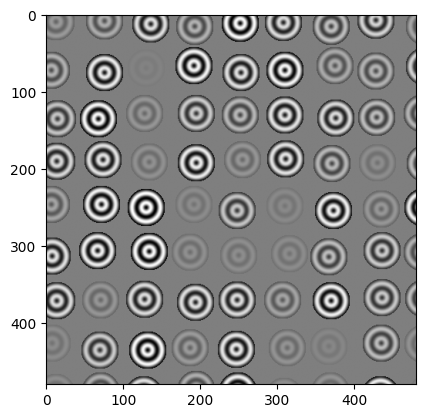

In [ ]:

contrast_range = 1
# fix the seed for reproducibility
np.random.seed(5)
stimulus_left = stimulus_generator.generate(scaling_factor, contrast_range, mean_contrast)

plt.imshow(stimulus_left, cmap='gray')

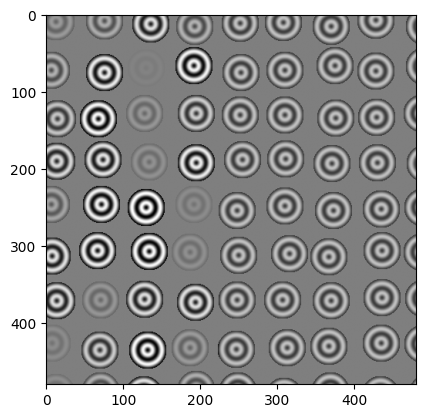

In [ ]:
stimulus = np.hstack((stimulus_left[:,:225], stimulus_right[:,225:]))

plt.imshow(stimulus, cmap='gray')

In [ ]:
model = V1Model(model_parameters, stimulus_parameters)
model.compute_omega(stimulus.flatten())

In [ ]:
state, time_vector = model.simulate(simulation_parameters)

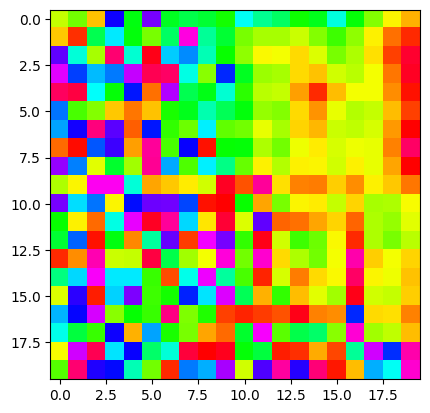

In [ ]:
reference = state[-1,10]

phase_differences = np.angle(np.exp(1j*(state[-1] - reference)))

plt.imshow(phase_differences.reshape(20,20), cmap='hsv', vmin=-np.pi, vmax=np.pi)

In [16]:
sync_index, _ = generate_time_index(simulation_parameters)

In [ ]:
synchronization_left = np.abs(order_parameter(state[:,:200]))
synchronization_right = np.abs(order_parameter(state[:,200:]))

sync_left = np.mean(synchronization_left[sync_index])
sync_right = np.mean(synchronization_right[sync_index])

print(f"Left synchronization: {sync_left}")
print(f"Right synchronization: {sync_right}")


Left synchronization: 0.4702482380902653
Right synchronization: 0.3692786470560636


In [ ]:
contrast_range = 0.
# fix the seed for reproducibility
np.random.seed(5)
stimulus = stimulus_generator.generate(scaling_factor, contrast_range, mean_contrast)

model.compute_omega(stimulus.flatten())
state, time_vector = model.simulate(simulation_parameters)

synchronization_left = np.abs(order_parameter(state[:,:200]))
synchronization_right = np.abs(order_parameter(state[:,200:]))

sync_left = np.mean(synchronization_left[sync_index])
sync_right = np.mean(synchronization_right[sync_index])

print(f"Left synchronization: {sync_left}")
print(f"Right synchronization: {sync_right}")

Left synchronization: 0.8450164480981879
Right synchronization: 0.7433700955978823


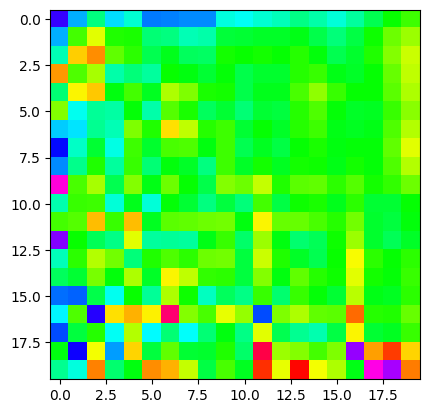

In [ ]:
reference = state[-1,10]

phase_differences = np.angle(np.exp(1j*(state[-1] - reference)))

plt.imshow(phase_differences.reshape(20,20), cmap='hsv', vmin=-np.pi, vmax=np.pi)